# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [3]:
# =========================
# 1. Import libraries
# =========================
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


# =========================
# 2. Load datasets
# =========================
heart_df = pd.read_csv("heart.csv")
nb_df = pd.read_csv("NBClean.csv")


# =========================
# 3. Processing function
# =========================
def process_dataset(df, target_column):

    # -------------------------
    # A. Separate X and y
    # -------------------------
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    # -------------------------
    # B. Identify column types
    # -------------------------
    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

    # Add known categorical columns (for heart dataset)
    known_cat = ['cp', 'restecg', 'slope', 'thal', 'sex', 'fbs', 'exang']
    categorical_cols = list(set(categorical_cols + [col for col in known_cat if col in X.columns]))

    numerical_cols = [col for col in X.columns if col not in categorical_cols]

    # -------------------------
    # C. Train-test split (UPDATED)
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.1,       # ✅ 10% test
        random_state=101,    # ✅ required
        stratify=y           # keeps class balance
    )

    # -------------------------
    # D. Pipelines
    # -------------------------
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])

    # -------------------------
    # E. Full pipeline
    # -------------------------
    model = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    # -------------------------
    # F. Train
    # -------------------------
    model.fit(X_train, y_train)

    # -------------------------
    # G. Evaluate
    # -------------------------
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Processed dataset with target = '{target_column}'")
    print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
    print(f"Accuracy: {acc:.4f}")
    print("-" * 40)

    return model


# =========================
# 4. Run for both datasets
# =========================

# Heart dataset
heart_model = process_dataset(heart_df, target_column="target")



Processed dataset with target = 'target'
Train size: 272 | Test size: 31
Accuracy: 0.8387
----------------------------------------


## Naive Bayes Model

**TASK: Create Naive Bayes model

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("heart.csv")

# Features and label
X = df.drop("target", axis=1)
y = df["target"]

# THIS creates X_train and X_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=101,
    stratify=y
)

In [6]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train)

# Transform both sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Create model
nb_model = GaussianNB()

# Train on scaled training data
nb_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = nb_model.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8064516129032258

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.93      0.81        14
           1       0.92      0.71      0.80        17

    accuracy                           0.81        31
   macro avg       0.82      0.82      0.81        31
weighted avg       0.83      0.81      0.81        31



## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[13  1]
 [ 5 12]]


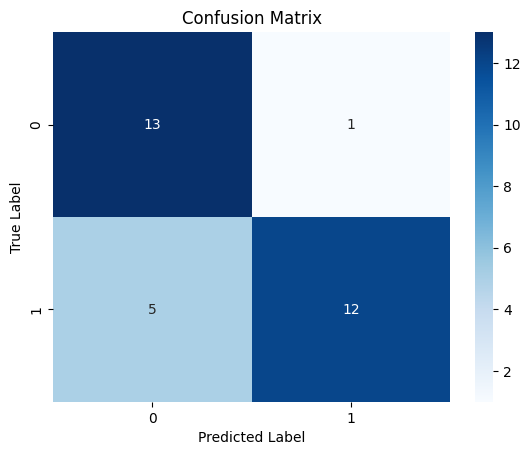

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [10]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.93      0.81        14
           1       0.92      0.71      0.80        17

    accuracy                           0.81        31
   macro avg       0.82      0.82      0.81        31
weighted avg       0.83      0.81      0.81        31



**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [11]:

import numpy as np

patient = np.array([[48.0, 0.0, 2.0, 130.0, 275.0, 0.0, 1.0,
                     139.0, 0.0, 0.2, 2.0, 0.0, 2.0]])

In [12]:
patient_scaled = scaler.transform(patient)

c:\Users\Alia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
prediction = nb_model.predict(patient_scaled)
print("Prediction:", prediction)

Prediction: [1]


In [14]:
probability = nb_model.predict_proba(patient_scaled)
print("Probabilities:", probability)

Probabilities: [[5.90831907e-04 9.99409168e-01]]
